In [1]:
from baseline_model.model.models import CustomEncoderDecoder, SimpleUNet
from baseline_model.trainer.trainer import Trainer
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np
from pathlib import Path
from tqdm import tqdm
import os
import torch
import pandas as pd
from torchcnnbuilder.preprocess.time_series import multi_output_tensor
from datetime import timedelta
from pathlib import Path

In [2]:
class MakeTimeSeriesPerWeek:
    """Prepares time-series datasets from daily .npy files.

    This class handles the full preprocessing pipeline:
    1.  Calculates precise date ranges for training, validation, and test sets
        by determining a cutoff date that ensures only full data windows can
        be formed.
    2.  Loads daily data matrices.
    3.  Aggregates (averages) the daily data into larger time steps (e.g.,
        weekly).
    4.  Slices the aggregated data into non-overlapping input/output windows
        for model training.
    """
    def __init__(self, year_val, year_test, time_descritization, 
                 pre_history_len, forecast_len, path):
        """Initializes the class with data processing parameters.

        Args:
            year_val (int): The year when the validation set begins.
            year_test (int): The year when the test set begins.
            time_descritization (int): The number of daily records to
                aggregate into a single time step (e.g., 7 for weekly).
            pre_history_len (int): The sequence length for the model's
                input (X).
            forecast_len (int): The sequence length for the model's
                prediction (Y).
            path (str): The path to the directory containing the daily .npy
                files.
        """
        self.year_val = year_val
        self.year_test = year_test
        self.time_descritization = time_descritization
        self.pre_history_len = pre_history_len
        self.forecast_len = forecast_len
        self.start_date = '1979-01-01'
        self.end_date = '2020-12-31'
        self.path = Path(path)

    def _make_time_descr(self):
        """Calculates the exact date ranges for the train, eval, and test sets.

        This method uses specific logic to ensure the generated data is
        sufficient for an integer number of full windows.

        1.  A large frequency `freq` is calculated based on the total window
            size.
        2.  This frequency is used to find "anchor" dates to determine the last
            possible date in each period (train/eval/test).
        3.  A continuous daily date range is then generated from the period's
            start to the calculated anchor end date.

        Returns:
            A tuple of three pd.DatetimeIndex objects for the train, eval, and
            test sets.
        """
        big_freq_value = self.time_descritization * (self.pre_history_len + self.forecast_len)
        big_freq_str = f'{big_freq_value}D'

        anchor_dates_train = pd.date_range(start=self.start_date,
                                       end=f'{self.year_val}-01-01',
                                       freq=big_freq_str)
        if len(anchor_dates_train) > 0:
            end_date_train = anchor_dates_train[-1]
            all_dates_train = pd.date_range(start=self.start_date, end=end_date_train, freq='D')
        else:
            all_dates_train = pd.DatetimeIndex([])

        start_date_eval = f'{self.year_val}-01-01'
        anchor_dates_eval = pd.date_range(start=start_date_eval,
                                      end=f'{self.year_test}-01-01',
                                      freq=big_freq_str)
        if len(anchor_dates_eval) > 0:
            end_date_eval = anchor_dates_eval[-1]
            all_dates_eval = pd.date_range(start=start_date_eval, end=end_date_eval, freq='D')
        else:
            all_dates_eval = pd.DatetimeIndex([])

        start_date_test = f'{self.year_test}-01-01'
        anchor_dates_test = pd.date_range(start=start_date_test,
                                      end=self.end_date,
                                      freq=big_freq_str)
        if len(anchor_dates_test) > 0:
            end_date_test = anchor_dates_test[-1]
            all_dates_test = pd.date_range(start=start_date_test, end=end_date_test, freq='D')
        else:
            all_dates_test = pd.DatetimeIndex([])

        return all_dates_train, all_dates_eval, all_dates_test
    
    def _prepare_name(self, name):
        """Constructs the full filepath for a given date.

        Args:
            name (pd.Timestamp): The date for which to create the filename.

        Returns:
            The full path to the .npy file as a pathlib.Path object.
        """
        name = name.strftime("%Y-%m-%d").replace('-', '')
        return self.path / Path('osisaf_' + name + '.npy')
    
    def _calc_time_descr(self, dates):
        """Loads and aggregates daily data into larger time steps.

        This method iterates through a list of daily dates, loads the
        corresponding .npy files, and averages them into blocks of
        `self.time_descritization` days.

        Args:
            dates (pd.DatetimeIndex): A list of daily dates to process.

        Returns:
            A list of aggregated tensors.
        """
        dates_matrixes = list()
        
        time_descr = list()
        for date in tqdm(dates):
            if len(time_descr) == self.time_descritization:
                time_descr = np.array(time_descr).mean(axis=0)
                time_descr = torch.from_numpy(time_descr)
                dates_matrixes.append(time_descr)
                time_descr = list()
            matrix = np.load(self._prepare_name(date))
            time_descr.append(matrix)
        
        return dates_matrixes
    
    def _make_matrix_from_dates(self):
        """Orchestrates the creation of lists of aggregated matrices."""
        train_dates, eval_dates, test_dates = self._make_time_descr()
        
        all_matrix_train = self._calc_time_descr(train_dates)
        all_matrix_eval = self._calc_time_descr(eval_dates)
        all_matrix_test = self._calc_time_descr(test_dates)
        
        return all_matrix_train, all_matrix_eval, all_matrix_test
    
    def _make_in_out_split(self, list_matrixes):
        """Slices a list of matrices into non-overlapping input/output windows.

        This method creates non-overlapping windows by using a step size equal
        to the full window length. To create overlapping windows (which would
        increase the sample size), the step should be changed to 1.

        Args:
            list_matrixes (List[torch.Tensor]): A list of aggregated matrices.

        Returns:
            A list of tuples, where each tuple is (X, Y), and X and Y are
            lists of tensors.
        """
        stop_index = len(list_matrixes) - (self.pre_history_len + self.forecast_len) + 1
    
        return [(list_matrixes[i : i + self.pre_history_len], 
                 list_matrixes[i + self.pre_history_len : i + self.pre_history_len + self.forecast_len]) 
                for i in range(0, stop_index, self.pre_history_len + self.forecast_len)]
    
    def load(self):
        train_matrixes, eval_matrixes, test_matrixes = self._make_matrix_from_dates()
        xy_pairs_train = self._make_in_out_split(train_matrixes)
        xy_pairs_eval = self._make_in_out_split(eval_matrixes)
        xy_pairs_test = self._make_in_out_split(test_matrixes)
        return xy_pairs_train, xy_pairs_eval, xy_pairs_test

In [3]:
class ArcticDataset(Dataset):
    def __init__(self, list_matrixes):
        self.matrixes = list_matrixes
        
    def __len__(self):
        return len(self.matrixes)
    
    def __getitem__(self, index):
        current_matrixes = self.matrixes[index]
        x = torch.stack(current_matrixes[0])
        y = torch.stack(current_matrixes[1])
        return x , y

In [4]:
maker = MakeTimeSeriesPerWeek(
    path= r'D:\artic\Benchmark\dataset\osisaf\osisaf',
    year_val=2017, 
    year_test=2019, 
    time_descritization=7, 
    pre_history_len=48, 
    forecast_len=24
)

train_matrix, eval_matrix, test_matrix = maker.load()

100%|██████████| 505/505 [00:04<00:00, 111.75it/s]


In [5]:
train_dataset = ArcticDataset(train_matrix)
eval_dataset = ArcticDataset(eval_matrix)
test_dataset = ArcticDataset(test_matrix)

In [6]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=False)
eval_dataloader = DataLoader(dataset=eval_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=8, shuffle=False)

In [7]:
model = CustomEncoderDecoder(num_layers=5, channels_in=48, channels_out=24, image_size=432)

In [8]:
trainer = Trainer(model=model)

100%|██████████| 2/2 [00:23<00:00, 11.87s/it]


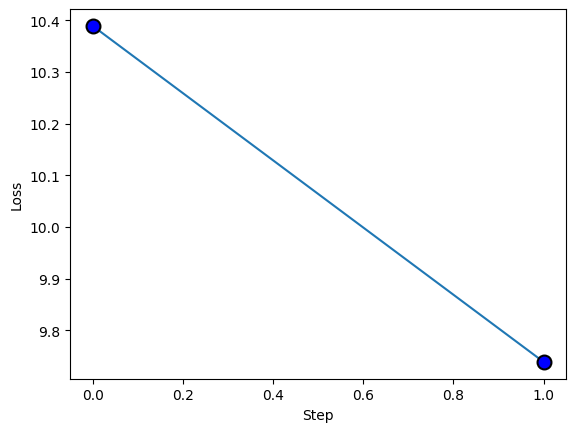

In [9]:
model = trainer.train(eval_dataloader, num_epoch=2, make_plot=True)

INFO:root:Eval logs ssim [0.801540195941925, 0.7858025431632996, 0.8305417895317078, 0.7877987027168274, 0.8025732040405273, 0.8025943040847778, 0.8605257868766785, 0.8080591559410095, 0.8005805015563965, 0.79549640417099, 0.8409721255302429, 0.8368033766746521, 0.8000101447105408, 0.8403000235557556, 0.8449390530586243, 0.8203996419906616, 0.8327746391296387, 0.8477326035499573, 0.7923538088798523, 0.8026437163352966, 0.8207434415817261, 0.841503918170929, 0.8263479471206665, 0.795822262763977]
INFO:root:Eval logs psnr [-45.37064552307129, -55.16472339630127, -37.687439918518066, -54.101319313049316, -47.50872611999512, -47.486634254455566, -25.712833404541016, -46.8125581741333, -49.920454025268555, -52.86512851715088, -25.82092523574829, -39.047067165374756, -51.285834312438965, -39.28150653839111, -37.73452043533325, -44.32258129119873, -39.53441381454468, -31.106882095336914, -53.1171989440918, -48.4508752822876, -42.369751930236816, -36.785409450531006, -38.92775774002075, -48.34

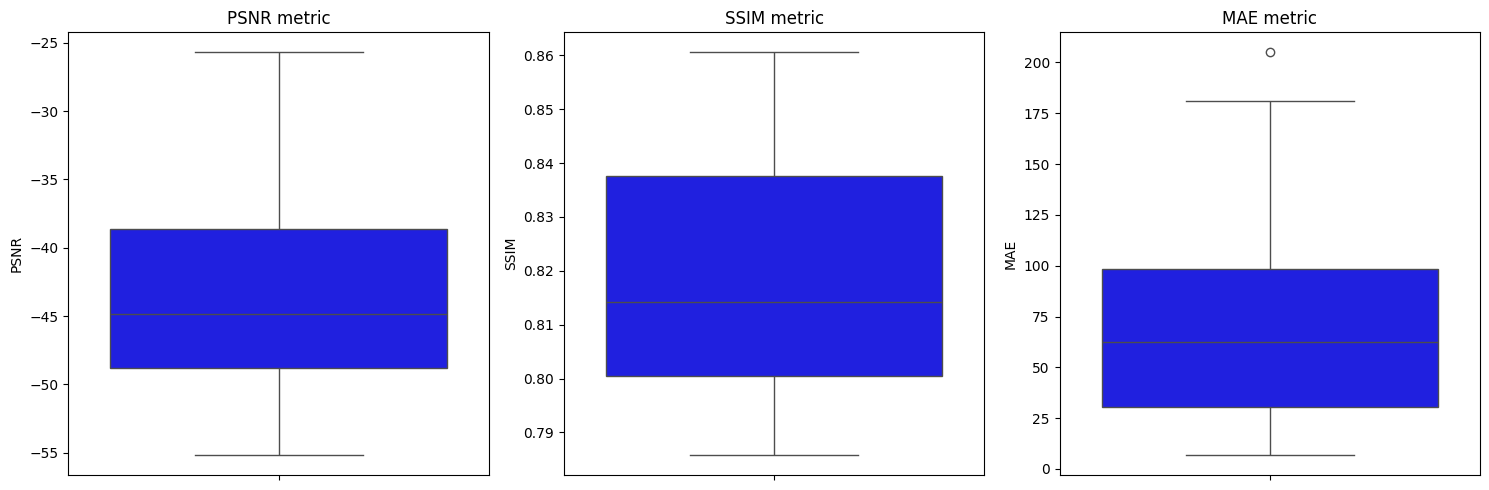

In [10]:
trainer.evaluate(eval_dataloader, make_plot=True)

INFO:root:Test logs ssim [0.7984099984169006, 0.7822668552398682, 0.827342689037323, 0.7850450873374939, 0.8005116581916809, 0.8003579378128052, 0.8620551824569702, 0.8065942525863647, 0.798014760017395, 0.792610764503479, 0.8449116945266724, 0.8363178372383118, 0.7962967157363892, 0.8407554030418396, 0.8455310463905334, 0.8194451332092285, 0.8338078856468201, 0.8445051908493042, 0.7883987426757812, 0.7986118793487549, 0.8173022866249084, 0.839017391204834, 0.8248015642166138, 0.7928096055984497]
INFO:root:Test logs psnr [-45.25300979614258, -55.05364418029785, -37.49654531478882, -53.97712707519531, -47.38462448120117, -47.360262870788574, -25.23402214050293, -46.671175956726074, -49.79796886444092, -52.73903846740723, -25.555379390716553, -38.84244441986084, -51.14759922027588, -39.093384742736816, -37.57820129394531, -44.16715621948242, -39.372923374176025, -30.94573974609375, -53.00519943237305, -48.33535194396973, -42.2651481628418, -36.64055347442627, -38.77690553665161, -48.2423

SSIM metric is 0.8156550650795301
----------
PSNR metric is -43.12232414881388
----------
MAE metric is 73.53603623310725


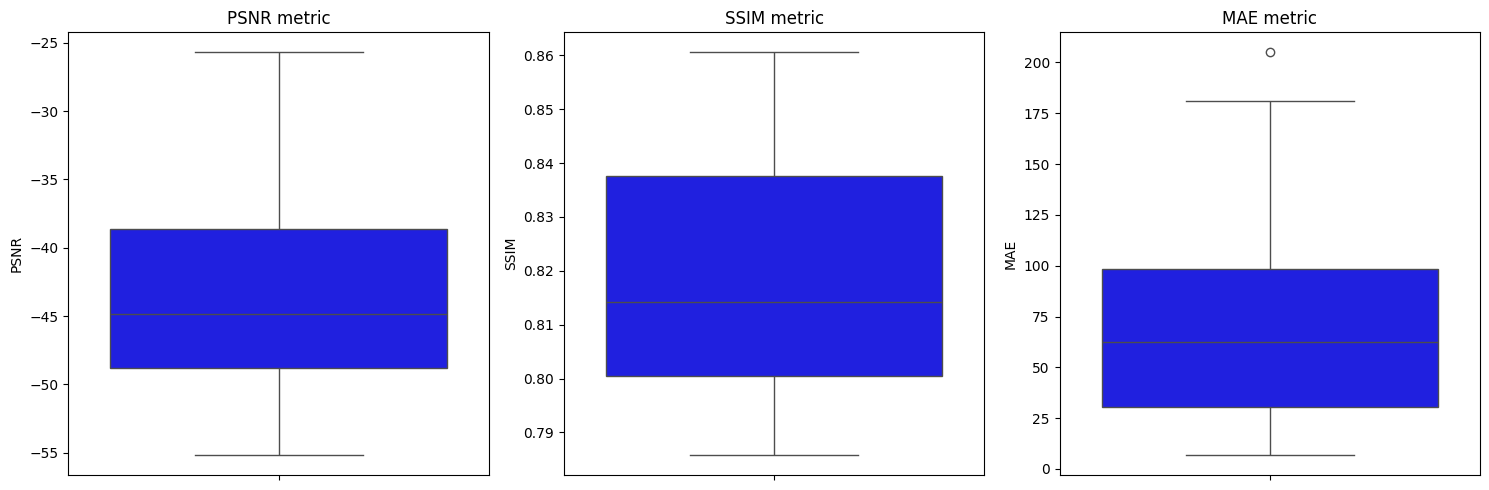

In [11]:
trainer.test(test_dataloader, make_plot = True)

In [12]:
model_unet = SimpleUNet(48, 24)

In [13]:
trainer_unet = Trainer(model=model_unet)

100%|██████████| 2/2 [00:07<00:00,  3.64s/it]


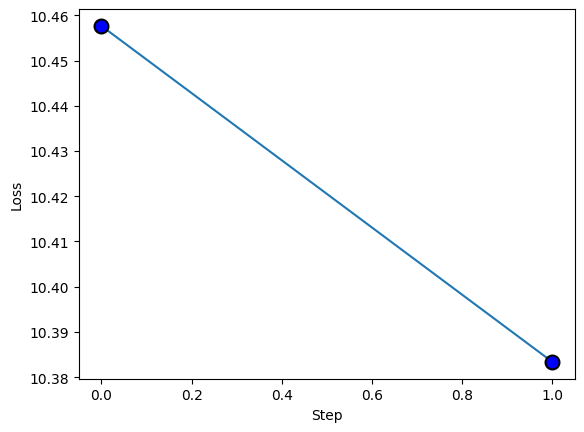

In [14]:
model_unet = trainer_unet.train(eval_dataloader, num_epoch=2, make_plot=True)

INFO:root:Eval logs ssim [0.8240712285041809, 0.8202388882637024, 0.8185911178588867, 0.8120163083076477, 0.8057445883750916, 0.8036027550697327, 0.8007734417915344, 0.802573025226593, 0.8013361692428589, 0.7903854846954346, 0.792932391166687, 0.7845076322555542, 0.792253851890564, 0.7921185493469238, 0.7889041900634766, 0.7901845574378967, 0.7905711531639099, 0.7908380627632141, 0.7941780090332031, 0.8028849363327026, 0.8073937892913818, 0.8185749053955078, 0.8281348943710327, 0.8262152671813965]
INFO:root:Eval logs psnr [-28.817195892333984, -29.00933265686035, -29.274842739105225, -29.477734565734863, -29.67198133468628, -29.654011726379395, -29.569756984710693, -29.812562465667725, -29.83912944793701, -29.961161613464355, -30.079350471496582, -30.075273513793945, -29.95121479034424, -30.033652782440186, -30.300304889678955, -29.944190979003906, -30.178656578063965, -30.08634090423584, -30.021283626556396, -30.00103235244751, -29.848878383636475, -29.39824104309082, -29.326102733612

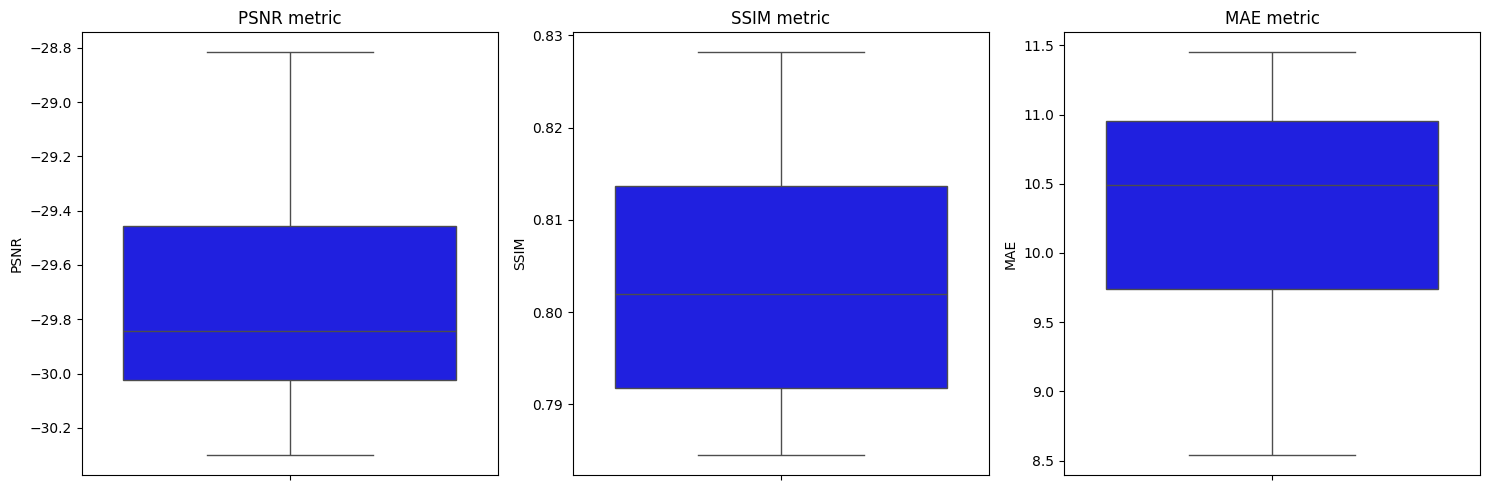

In [15]:
trainer_unet.evaluate(eval_dataloader, make_plot=True)

INFO:root:Test logs ssim [0.824142575263977, 0.8206512331962585, 0.8188125491142273, 0.8090843558311462, 0.8036032915115356, 0.8024835586547852, 0.8001152276992798, 0.7991637587547302, 0.7992933988571167, 0.7877712249755859, 0.7908809781074524, 0.7833916544914246, 0.7912417650222778, 0.7904224991798401, 0.7880153656005859, 0.7923946380615234, 0.7924984097480774, 0.791075587272644, 0.7970656156539917, 0.8039232492446899, 0.8069753646850586, 0.8120982646942139, 0.825187623500824, 0.8239559531211853]
INFO:root:Test logs psnr [-28.863275051116943, -29.104554653167725, -29.422507286071777, -29.74722385406494, -29.76151466369629, -29.780802726745605, -29.736151695251465, -30.002779960632324, -29.996416568756104, -30.23789644241333, -30.291056632995605, -30.280680656433105, -30.263516902923584, -30.28228759765625, -30.315821170806885, -29.97994899749756, -30.083892345428467, -30.058112144470215, -30.041475296020508, -29.977033138275146, -29.738290309906006, -29.400434494018555, -29.3329787254

SSIM metric is 0.8022603392601013
----------
PSNR metric is -29.825380245844524
----------
MAE metric is 10.54541289806366


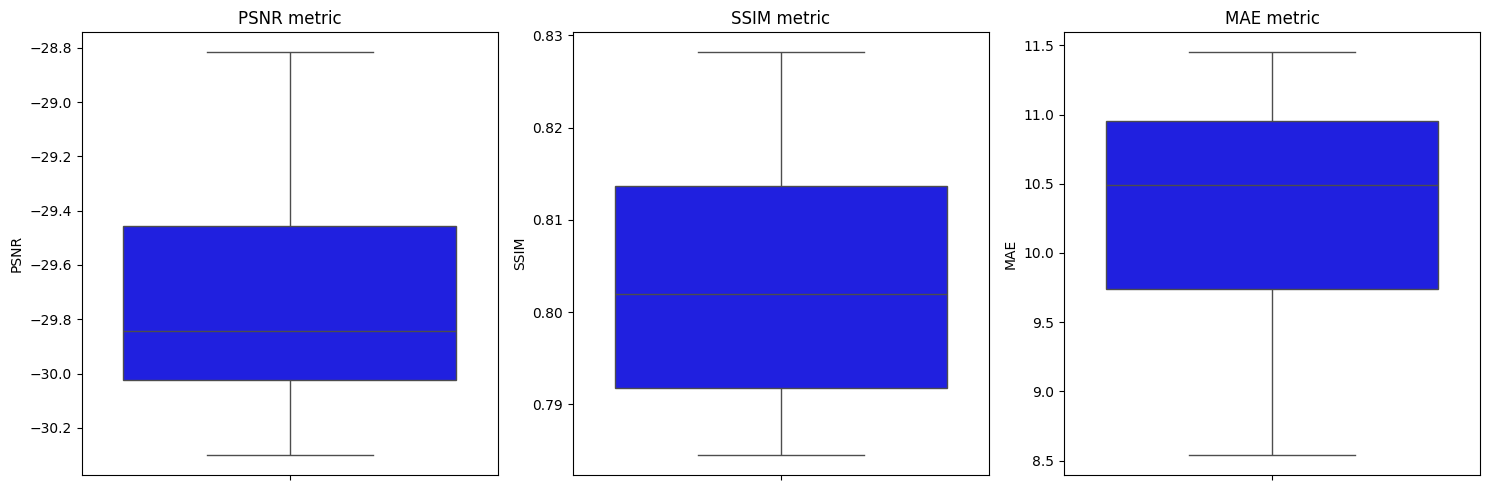

In [16]:
trainer_unet.test(test_dataloader, make_plot = True)